# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of this experiment is to determine how different burrito ingredients, including protein type, salsa type, and potato inclusion, affect customer satisfaction ratings and to identify which ingredient combination produces the highest overall satisfaction.

2. State the outcome variable and how it was measured.

The outcome variable is **customer satisfaction rating**.

It is a quantitative variable measured on a scale from **1 to 10**, where:

- **1 = terrible**
- **10 = amazing**

Each participant rated the burrito they tasted after being randomly assigned to a treatment combination.

3. State the main effects. What lurking variables may be present?

The main effects in this experiment are:

- **Protein**
  - Bacon
  - Sausage
  - Chorizo

- **Salsa**
  - Mild
  - Hot

- **Potatoes**
  - Yes
  - No

Possible lurking variables include:

- participant spice tolerance
- individual food preferences
- hunger level before tasting
- burrito serving temperature
- ingredient freshness
- portion size differences
- previous experience with breakfast burritos
- mood or fatigue during tasting

These variables may influence satisfaction ratings even though they were not directly controlled in the experiment.

4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?

A full factorial design is preferred because one factor in this experiment, protein type, contains 3 levels instead of 2, so the experiment does not naturally fit a standard $2^k$ fractional factorial structure.

Using the full factorial design allows all treatment combinations and interaction effects to be examined directly. Since food preferences may depend on combinations of ingredients rather than individual ingredients alone, evaluating all combinations is useful.

In this experiment, the total number of treatment combinations is still manageable:

$$
3 \times 2 \times 2 = 12
$$

so there is less need to reduce the design using a fractional factorial approach.

Although a fractional design could reduce time and cost, some effects would become aliased, making interpretation more difficult.

5. State all sets of statistical hypotheses.

Let:

- $\mu_{Bacon}, \mu_{Sausage}, \mu_{Chorizo}$ represent the mean satisfaction ratings for protein types
- $\mu_{Hot}, \mu_{Mild}$ represent the mean satisfaction ratings for salsa types
- $\mu_{No}, \mu_{Yes}$ represent the mean satisfaction ratings for potato levels

### Main Effect of Protein

$$
H_0: \mu_{Bacon} = \mu_{Sausage} = \mu_{Chorizo}
$$

$$
H_A: \text{At least one protein mean differs}
$$

---

### Main Effect of Salsa

$$
H_0: \mu_{Hot} = \mu_{Mild}
$$

$$
H_A: \mu_{Hot} \ne \mu_{Mild}
$$
---

### Main Effect of Potatoes

$$
H_0: \mu_{No} = \mu_{Yes}
$$

$$
H_A: \mu_{No} \ne \mu_{Yes}
$$

---

### Protein × Salsa Interaction

$$
H_0: \text{There is no Protein × Salsa interaction}
$$

$$
H_A: \text{There is a Protein × Salsa interaction}
$$
---

### Protein × Potatoes Interaction

$$
H_0: \text{There is no Protein × Potatoes interaction}
$$

$$
H_A: \text{There is a Protein × Potatoes interaction}
$$

---

### Salsa × Potatoes Interaction

$$
H_0: \text{There is no Salsa × Potatoes interaction}
$$

$$
H_A: \text{There is a Salsa × Potatoes interaction}
$$

---

### Three-Way Interaction

$$
H_0: \text{There is no three-way interaction}
$$

$$
H_A: \text{There is a three-way interaction}
$$

## 6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


  Protein Salsa Potatoes  Satisfaction
0   Bacon  Mild      Yes           6.1
1   Bacon  Mild      Yes           6.9
2   Bacon  Mild      Yes           6.9
3   Bacon  Mild      Yes           9.4
4   Bacon  Mild      Yes           5.4

Summary Statistics:
       Satisfaction
count     60.000000
mean       6.350000
std        1.123026
min        3.100000
25%        5.900000
50%        6.400000
75%        6.900000
max        9.700000

Mean Satisfaction by Protein:
Protein
Bacon      6.49
Chorizo    6.74
Sausage    5.82
Name: Satisfaction, dtype: float64

Mean Satisfaction by Salsa:
Salsa
Hot     6.073333
Mild    6.626667
Name: Satisfaction, dtype: float64

Mean Satisfaction by Potatoes:
Potatoes
No     6.11
Yes    6.59
Name: Satisfaction, dtype: float64

Mean Satisfaction by Treatment Combination:
    Protein Salsa Potatoes  Satisfaction
0     Bacon   Hot       No          5.86
1     Bacon   Hot      Yes          6.46
2     Bacon  Mild       No          6.70
3     Bacon  Mild      Yes    

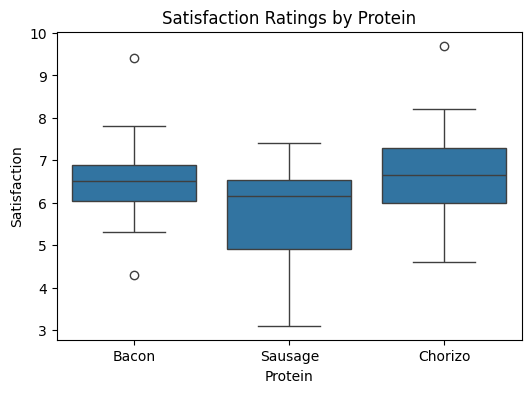

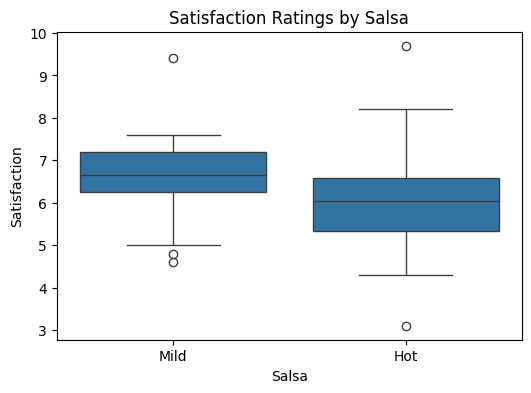

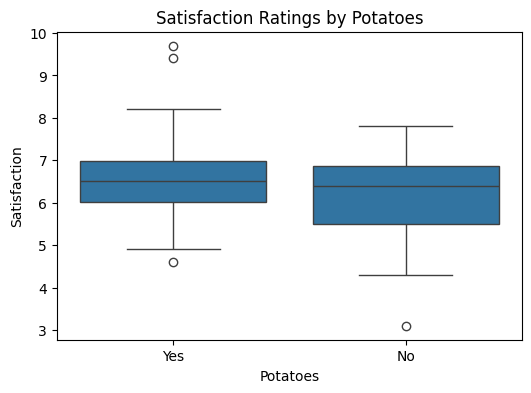

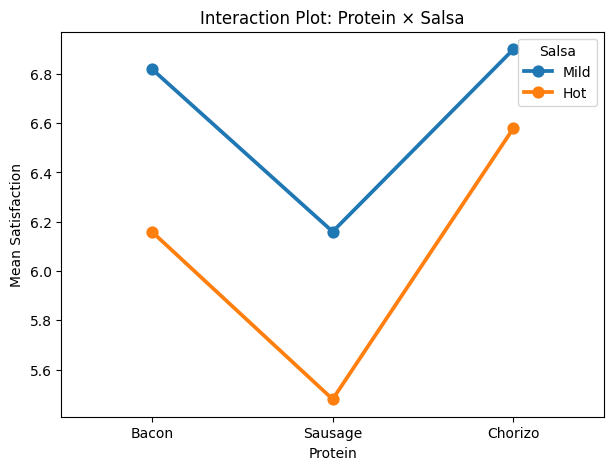

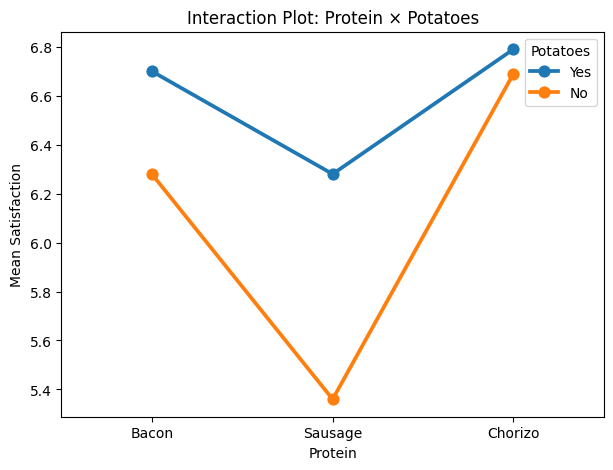

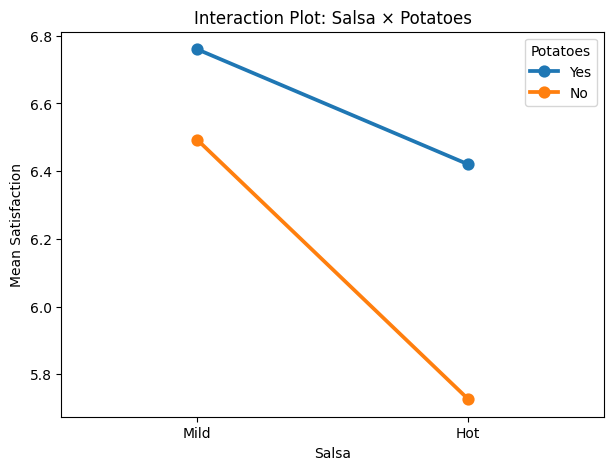

In [1]:
## Question 6 Code ##
# Question 6 Code

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("Busters Burritos.xlsx")

# Display first few rows
print(df.head())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Mean satisfaction by Protein
protein_means = df.groupby("Protein")["Satisfaction"].mean()
print("\nMean Satisfaction by Protein:")
print(protein_means)

# Mean satisfaction by Salsa
salsa_means = df.groupby("Salsa")["Satisfaction"].mean()
print("\nMean Satisfaction by Salsa:")
print(salsa_means)

# Mean satisfaction by Potatoes
potato_means = df.groupby("Potatoes")["Satisfaction"].mean()
print("\nMean Satisfaction by Potatoes:")
print(potato_means)

# Mean satisfaction by full treatment combination
combo_means = (
    df.groupby(["Protein", "Salsa", "Potatoes"])["Satisfaction"]
    .mean()
    .reset_index()
)

print("\nMean Satisfaction by Treatment Combination:")
print(combo_means)

# -----------------------------
# Boxplot by Protein
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Protein", y="Satisfaction")
plt.title("Satisfaction Ratings by Protein")
plt.show()

# -----------------------------
# Boxplot by Salsa
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Salsa", y="Satisfaction")
plt.title("Satisfaction Ratings by Salsa")
plt.show()

# -----------------------------
# Boxplot by Potatoes
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Potatoes", y="Satisfaction")
plt.title("Satisfaction Ratings by Potatoes")
plt.show()

# -----------------------------
# Interaction Plot:
# Protein × Salsa
# -----------------------------
plt.figure(figsize=(7,5))

sns.pointplot(
    data=df,
    x="Protein",
    y="Satisfaction",
    hue="Salsa",
    errorbar=None
)

plt.title("Interaction Plot: Protein × Salsa")
plt.ylabel("Mean Satisfaction")
plt.show()

# -----------------------------
# Interaction Plot:
# Protein × Potatoes
# -----------------------------
plt.figure(figsize=(7,5))

sns.pointplot(
    data=df,
    x="Protein",
    y="Satisfaction",
    hue="Potatoes",
    errorbar=None
)

plt.title("Interaction Plot: Protein × Potatoes")
plt.ylabel("Mean Satisfaction")
plt.show()

# -----------------------------
# Interaction Plot:
# Salsa × Potatoes
# -----------------------------
plt.figure(figsize=(7,5))

sns.pointplot(
    data=df,
    x="Salsa",
    y="Satisfaction",
    hue="Potatoes",
    errorbar=None
)

plt.title("Interaction Plot: Salsa × Potatoes")
plt.ylabel("Mean Satisfaction")
plt.show()

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 7 Code ##

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [ ]:
## Question 9 Code ##

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [ ]:
## Question 10 Code ##

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [ ]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [ ]:
## Question 6 Code ##

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3.  What is the most important thing you learned in this class?